In [ ]:
import random
random.seed(42)
n_objetos = 200
capacidad_mochila = 600

limite_objetos = n_objetos // 3

objetos_peso = [random.randint(3, 60) for _ in range(n_objetos)]
objetos_valor = [random.randint(10, 150) for _ in range(n_objetos)]
objetos_cantidad = [random.randint(2, 15) for _ in range(n_objetos)]

print("Pesos:", objetos_peso)
print("Valores:", objetos_valor)
print("Cantidades:", objetos_cantidad)
print("Capacidad mochila:", capacidad_mochila)
capacidad_maxima_objetos = [capacidad_mochila // w if w > 0 else capacidad_mochila for w in objetos_peso]

N = len(objetos_peso)

Pesos: [43, 10, 4, 50, 20, 18, 17, 11, 50, 9, 46, 50, 60, 37, 8, 40, 30, 5, 4, 8, 16, 17, 35, 41, 4, 38, 15, 48, 44, 47, 37, 29, 17, 31, 40, 20, 54, 58, 3, 51, 54, 13, 47, 30, 24, 20, 12, 16, 51, 24, 9, 8, 27, 9, 25, 57, 25, 41, 19, 54, 5, 49, 32, 37, 10, 27, 8, 38, 21, 56, 43, 42, 59, 58, 26, 39, 15, 48, 7, 5, 45, 17, 52, 21, 8, 57, 17, 58, 9, 27, 20, 32, 43, 56, 26, 13, 26, 25, 16, 45, 20, 47, 46, 44, 7, 41, 43, 13, 37, 49, 18, 13, 32, 27, 20, 43, 47, 38, 17, 46, 23, 56, 52, 52, 6, 17, 55, 5, 54, 23, 28, 20, 7, 16, 39, 59, 48, 23, 16, 44, 34, 28, 59, 44, 32, 12, 19, 11, 18, 50, 38, 37, 19, 50, 40, 30, 60, 40, 28, 26, 17, 11, 35, 34, 8, 51, 6, 58, 10, 12, 43, 13, 53, 46, 30, 41, 7, 27, 27, 41, 32, 36, 19, 38, 58, 3, 46, 49, 10, 46, 59, 37, 51, 20, 52, 44, 24, 10, 21, 30]
Valores: [50, 126, 10, 77, 138, 55, 139, 37, 86, 139, 60, 49, 105, 51, 148, 145, 10, 92, 135, 14, 38, 102, 88, 71, 24, 71, 30, 31, 134, 27, 146, 42, 42, 131, 150, 52, 77, 145, 118, 64, 148, 61, 89, 112, 105, 122, 142,

# Funciones para utilizar en el algoritmo de enfriamiento simulado

In [ ]:
def create_restricciones():
    restricciones = {"separados": {}, "juntos": {}}

    for _ in range(int(n_objetos // 2)):
        # Primero generamos las restricciones de que un objeto no puede estar con otro
        objeto = random.randint(0, N - 1)
        otro_objeto = random.randint(0, N - 1)
        while otro_objeto == objeto:
            otro_objeto = random.randint(0, N - 1)
        if objeto not in restricciones["separados"]:
            restricciones["separados"][objeto] = set()
        restricciones["separados"][objeto].add(otro_objeto)

    for _ in range(int(n_objetos // 2)):
        objeto = random.randint(0, N - 1)
        otro_objeto = random.randint(0, N - 1)
        while otro_objeto == objeto:
            otro_objeto = random.randint(0, N - 1)
        if objeto not in restricciones["juntos"]:
            restricciones["juntos"][objeto] = set()
        restricciones["juntos"][objeto].add(otro_objeto)

    return restricciones

restricciones = create_restricciones()
print("Restricciones:", restricciones)

Restricciones: {'separados': {121: {156, 188}, 43: {168}, 21: {72}, 131: {169}, 162: {158}, 85: {23}, 192: {107, 60, 63}, 172: {79}, 57: {50, 166}, 37: {6}, 11: {62}, 196: {18, 199}, 116: {106, 83}, 161: {147}, 49: {183}, 178: {98, 132, 5}, 126: {102}, 62: {37}, 167: {176}, 1: {192, 90}, 197: {27, 149}, 199: {108}, 56: {45}, 118: {12}, 142: {63}, 31: {116}, 34: {118}, 170: {135}, 143: {152}, 81: {193, 138}, 113: {156}, 184: {129}, 109: {140}, 114: {40}, 190: {121}, 115: {66}, 163: {70}, 133: {124}, 160: {61}, 70: {112}, 19: {182}, 73: {60}, 69: {85, 111}, 20: {35}, 38: {59}, 98: {177}, 39: {180, 61}, 54: {16}, 106: {104}, 84: {138}, 119: {106}, 15: {52}, 107: {99}, 195: {147}, 97: {122, 71}, 76: {192}, 99: {107, 86}, 137: {191}, 188: {139}, 154: {56}, 124: {56, 7}, 171: {173}, 103: {185}, 42: {119}, 32: {159}, 136: {6}, 100: {151}, 144: {169}, 6: {21}, 164: {109}, 46: {12}, 66: {97}, 83: {54}, 86: {194}, 64: {20}, 120: {4}, 191: {138}, 13: {89}, 17: {199}, 166: {10}, 193: {7}, 63: {51}

In [ ]:
def validar(individuo):

    restricciones_violadas = []
    # Validar restricciones de que ciertos objetos no pueden estar juntos
    for objeto, separados in restricciones["separados"].items():
        if individuo[objeto] > 0:
            for otro_objeto in separados:
                if individuo[otro_objeto] > 0:
                    restricciones_violadas.append("separados")
                    break

    # Validar restricciones de que ciertos objetos deben estar juntos
    for objeto, juntos in restricciones["juntos"].items():
        if individuo[objeto] > 0:
            for otro_objeto in juntos:
                if individuo[otro_objeto] == 0:
                    #print("Falla en juntos:", objeto, otro_objeto)
                    restricciones_violadas.append("juntos")
                    break

    if len(restricciones_violadas) == 0:
        return True, []
    else:
        return False, restricciones_violadas

In [ ]:
import random
def populate():
    individual = []
    remaining_w = capacidad_mochila
    remaining_c = limite_objetos
    for i in range(N):
        maxx = min(objetos_cantidad[i], remaining_w // objetos_peso[i], remaining_c)
        cant = random.randint(0, maxx)
        individual.append(cant)
        remaining_w -= cant * objetos_peso[i]
        remaining_c -= cant
    return individual

In [ ]:
def fitness(individuo):
    peso_total = 0
    valor_total = 0
    cantidad_total = 0

    for i in range(N):
        peso_total += individuo[i] * objetos_peso[i]
        valor_total += individuo[i] * objetos_valor[i]
        cantidad_total += individuo[i]

    valido, tipo_violacion = validar(individuo)

    penalizacion = 0

    # Penalización por exceso de peso
    if peso_total > capacidad_mochila:
        exceso_peso = peso_total - capacidad_mochila
        penalizacion += exceso_peso * 10

    # Penalización por exceso de objetos
    if cantidad_total > limite_objetos:
        exceso_objetos = cantidad_total - limite_objetos
        penalizacion += exceso_objetos * 50

    # Penalizaciones por violación de restricciones
    if not valido:
        penalizaciones_por_tipo = {
            "separados": 1000,
            "juntos": 1000,
        }
        for v in tipo_violacion:
            penalizacion += penalizaciones_por_tipo.get(v, 1000)

    return valor_total - penalizacion

# Algoritmo 1 de enfriamiento simulado

El algoritmo obtiene los vecinos recorriendo de forma secuencial al inidividuo y modificando la cantidad de objetos en dicha posición entre 0 y su capacidad máxima (objetos_cantidad[j])

In [ ]:
import random
from math import exp
def simulated_annealing(individuo, objetos_cantidad, fitness, validar,
                        T_inicial=50, T_min=1e-3, alpha=0.95, max_iter=5000, verbose=False):
    fitness_history = []
    mejor = individuo[:]
    individuo_actual = individuo[:]

    fitness_actual = fitness(individuo_actual)
    max_fitness = fitness_actual

    generaciones_sin_mejora = 0
    max_generaciones_sin_mejora = 500

    T = T_inicial
    i = 0

    while i <= max_iter and T > T_min:
        for j in range(len(individuo_actual)):
            cambio = False
            for k in range(objetos_cantidad[j]):
                prev = individuo_actual[j]
                # Generamos el vecino cambiando la cantidad del objeto j a k
                individuo_actual[j] = k

                nuevo_fitness = fitness(individuo_actual)
                diferencia = nuevo_fitness - fitness_actual

                # como funcion de probabilidad usamos e^(diferencia / T)
                if diferencia > 0 or random.random() < exp(diferencia / T):
                    fitness_actual = nuevo_fitness

                    if nuevo_fitness > max_fitness:
                        cambio = True
                        max_fitness = nuevo_fitness
                        mejor = individuo_actual[:]
                else:
                    # Deshacemos cambio si el nuevo individuo no es aceptado
                    individuo_actual[j] = prev
        if not cambio:
            generaciones_sin_mejora += 1
        if generaciones_sin_mejora >= max_generaciones_sin_mejora:
            individuo_actual = populate()
            fitness_actual = fitness(individuo_actual)
            if verbose:
                print("No hay mejora en", max_generaciones_sin_mejora, "generaciones, reiniciando individuo...")
            generaciones_sin_mejora = 0

        T *= alpha
        i += 1

        fitness_history.append(max_fitness)
        if verbose:
            print(f"Iteración {i} | T={T:.4f} | Mejor fitness={max_fitness} | Es válido: {validar(mejor)}")

    return mejor, max_fitness, fitness_history

# Algoritmo 2 de enfriamiento simulado

Se recorre el indivudo de forma secuencial pero se modifica cada posición bien quitandole un elemento o añadiéndole uno

In [ ]:
import random
from math import exp
def simulated_annealing2(individuo, objetos_cantidad, fitness, validar,
                        T_inicial=50, T_min=1e-3, alpha=0.95, max_iter=5000, verbose=False):
    fitness_history = []
    mejor = individuo[:]
    individuo_actual = individuo[:]

    fitness_actual = fitness(individuo_actual)
    max_fitness = fitness_actual

    generaciones_sin_mejora = 0
    max_generaciones_sin_mejora = 500

    T = T_inicial
    i = 0

    while i <= max_iter and T > T_min:
        cambio = False
        for j in range(len(individuo_actual)):
            for k in [-1, 1]:
                prev = individuo_actual[j]
                # Generamos el vecino cambiando quitando o añadiendo una unidad del objeto j
                if individuo_actual[j] == 0 and k == -1:
                    continue
                if k == 1 and individuo_actual[j] == objetos_cantidad[j]:
                    continue
                individuo_actual[j] += k

                nuevo_fitness = fitness(individuo_actual)
                diferencia = nuevo_fitness - fitness_actual

                # como funcion de probabilidad usamos e^(diferencia / T)
                if diferencia > 0 or random.random() < exp(diferencia / T):
                    fitness_actual = nuevo_fitness

                    if nuevo_fitness > max_fitness:
                        max_fitness = nuevo_fitness
                        mejor = individuo_actual[:]
                        cambio = True
                else:
                    # Deshacemos cambio si el nuevo individuo no es aceptado
                    individuo_actual[j] = prev
        if not cambio:
            generaciones_sin_mejora += 1
        if generaciones_sin_mejora >= max_generaciones_sin_mejora:
            individuo_actual = populate()
            fitness_actual = fitness(individuo_actual)
            if verbose:
                print("No hay mejora en", max_generaciones_sin_mejora, "generaciones, reiniciando individuo...")
            generaciones_sin_mejora = 0

        T *= alpha
        i += 1

        fitness_history.append(max_fitness)
        if verbose:
            print(f"Iteración {i} | T={T:.4f} | Mejor fitness={max_fitness} | Es válido: {validar(mejor)}")
        #print("Mejor individuo:", mejor)
        #print("Es válido:", validar(mejor))

    return mejor, max_fitness, fitness_history


# Algoritmo 3 de enfriamiento simulado

Algoritmo que para generar individuos utiliza la función de mutación definido en el algoritmo genético

In [ ]:
import random
from math import exp

def simulated_annealing3(individuo, objetos_cantidad, fitness, validar,
                        T_inicial=50, T_min=1e-3, alpha=0.95, max_iter=5000, verbose=False):
    fitness_history = []
    mejor = individuo[:]
    individuo_actual = individuo[:]

    fitness_actual = fitness(individuo_actual)
    max_fitness = fitness_actual

    generaciones_sin_mejora = 0
    max_generaciones_sin_mejora = 500

    T = T_inicial
    i = 0

    while i <= max_iter and T > T_min:
        cambio = False
        for j in range(len(individuo_actual)):
            prev = individuo_actual[j]
            # Generamos el vecino cambiando quitando o añadiendo una unidad del objeto j

            if random.random() < 0.5:
                individuo_actual[j] = random.randint(0, objetos_cantidad[j])

            nuevo_fitness = fitness(individuo_actual)
            diferencia = nuevo_fitness - fitness_actual

            # como funcion de probabilidad usamos e^(diferencia / T)
            if diferencia > 0 or random.random() < exp(diferencia / T):
                fitness_actual = nuevo_fitness

                if nuevo_fitness > max_fitness:
                    max_fitness = nuevo_fitness
                    mejor = individuo_actual[:]
                    cambio = True
            else:
                # Deshacemos cambio si el nuevo individuo no es aceptado
                individuo_actual[j] = prev
        if not cambio:
            generaciones_sin_mejora += 1
        if generaciones_sin_mejora >= max_generaciones_sin_mejora:
            individuo_actual = populate()
            fitness_actual = fitness(individuo_actual)
            if verbose:
                print("No hay mejora en", max_generaciones_sin_mejora, "generaciones, reiniciando individuo...")
            generaciones_sin_mejora = 0

        T *= alpha
        i += 1

        fitness_history.append(max_fitness)
        if verbose:
            print(f"Iteración {i} | T={T:.4f} | Mejor fitness={max_fitness} | Es válido: {validar(mejor)}")
        #print("Mejor individuo:", mejor)
        #print("Es válido:", validar(mejor))

    return mejor, max_fitness, fitness_history


# Pruebas para ver entre los 3 tipos de algoritmos de enfriamiento simulado cual funciona mejor

In [ ]:
ganador_generaciones = []

for i in range(100):
    individuo = populate()
    import random
    random.seed(i)
    n_objetos = 200
    capacidad_mochila = 600

    limite_objetos = n_objetos // 3

    objetos_peso = [random.randint(3, 60) for _ in range(n_objetos)]
    objetos_valor = [random.randint(10, 150) for _ in range(n_objetos)]
    objetos_cantidad = [random.randint(2, 15) for _ in range(n_objetos)]
    mejor, max_fit1, fitness_history = simulated_annealing(individuo, objetos_cantidad, fitness, validar, T_inicial=100, T_min=1e-5, alpha=0.95, max_iter=5000)
    mejor, max_fit2, fitness_history = simulated_annealing2(individuo, objetos_cantidad, fitness, validar, T_inicial=100, T_min=1e-5, alpha=0.95, max_iter=5000)
    mejor, max_fit3, fitness_history = simulated_annealing3(individuo, objetos_cantidad, fitness, validar, T_inicial=100, T_min=1e-5, alpha=0.95, max_iter=5000)

    if max_fit1 >= max_fit2 and max_fit1 >= max_fit3:
        ganador_generaciones.append("simmulated_annealing")
    elif max_fit2 >= max_fit1 and max_fit2 >= max_fit3:
        ganador_generaciones.append("simmulated_annealing2")
    elif max_fit3 >= max_fit1 and max_fit3 >= max_fit2:
        ganador_generaciones.append("simmulated_annealing3")
    print(f"Iteración {i+1}/100 completada")

Iteración 1/100 completada
Iteración 2/100 completada
Iteración 3/100 completada
Iteración 4/100 completada
Iteración 5/100 completada
Iteración 6/100 completada
Iteración 7/100 completada
Iteración 8/100 completada
Iteración 9/100 completada
Iteración 10/100 completada
Iteración 11/100 completada
Iteración 12/100 completada
Iteración 13/100 completada
Iteración 14/100 completada
Iteración 15/100 completada
Iteración 16/100 completada
Iteración 17/100 completada
Iteración 18/100 completada
Iteración 19/100 completada
Iteración 20/100 completada
Iteración 21/100 completada
Iteración 22/100 completada
Iteración 23/100 completada
Iteración 24/100 completada
Iteración 25/100 completada
Iteración 26/100 completada
Iteración 27/100 completada
Iteración 28/100 completada
Iteración 29/100 completada
Iteración 30/100 completada
Iteración 31/100 completada
Iteración 32/100 completada
Iteración 33/100 completada
Iteración 34/100 completada
Iteración 35/100 completada
Iteración 36/100 completada
I

In [ ]:
print(ganador_generaciones)

['simmulated_annealing2', 'simmulated_annealing', 'simmulated_annealing2', 'simmulated_annealing', 'simmulated_annealing2', 'simmulated_annealing', 'simmulated_annealing2', 'simmulated_annealing2', 'simmulated_annealing2', 'simmulated_annealing2', 'simmulated_annealing2', 'simmulated_annealing3', 'simmulated_annealing2', 'simmulated_annealing2', 'simmulated_annealing2', 'simmulated_annealing2', 'simmulated_annealing2', 'simmulated_annealing3', 'simmulated_annealing2', 'simmulated_annealing', 'simmulated_annealing2', 'simmulated_annealing2', 'simmulated_annealing2', 'simmulated_annealing2', 'simmulated_annealing2', 'simmulated_annealing2', 'simmulated_annealing2', 'simmulated_annealing2', 'simmulated_annealing2', 'simmulated_annealing2', 'simmulated_annealing2', 'simmulated_annealing', 'simmulated_annealing2', 'simmulated_annealing', 'simmulated_annealing2', 'simmulated_annealing2', 'simmulated_annealing', 'simmulated_annealing', 'simmulated_annealing2', 'simmulated_annealing3', 'simmul

In [ ]:
from collections import Counter

c = Counter(ganador_generaciones)
print(c)

Counter({'simmulated_annealing2': 78, 'simmulated_annealing': 15, 'simmulated_annealing3': 7})


## Gráfica con los resultados

El tercer metodo corresponde con simmulated_annealing2
El segundo método corresponde con simmulated_annealing
El primer método corresponde con simmulated_annealing3

Está en este orden por como se ha explicado en el informe, donde el primer método es el algoritmo de enfriamiento simulado utilizando la mutación, el segundo es el cambio de cada gen por una cantidad entre 0 y su máximo y el tercero es el cambio de cada gen quitándole o añadiéndole un elemento.

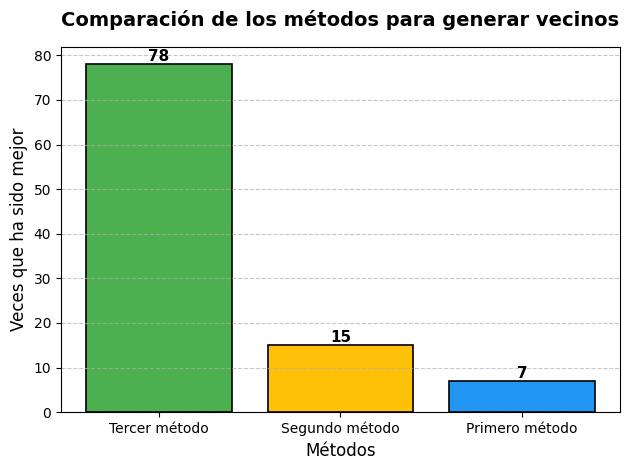

In [ ]:
import matplotlib.pyplot as plt

keys = ['Tercer método', 'Segundo método', 'Primero método']
colors = ['#4CAF50', '#FFC107', '#2196F3']

bars = plt.bar(keys, c.values(), color=colors, edgecolor='black', linewidth=1.2)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.05,
        f'{height}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.title('Comparación de los métodos para generar vecinos', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Métodos', fontsize=12)
plt.ylabel('Veces que ha sido mejor', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

# Aleatorización de simmulated_annealing2

Para intentar mejorar el algoritmo quité la iteración del individuo de forma secuencial para recorrer cada gen del individuo de forma aleatoria. De esta forma quizá podía obtener más variabilidad

In [ ]:
import random
from math import exp

def simulated_annealing_aleatorizado(individuo, objetos_cantidad, fitness, validar,
                                              T_inicial=50, T_min=1e-3, alpha=0.95,
                                              max_iter=5000, verbose=False):
    fitness_history = []
    mejor = individuo[:]
    individuo_actual = individuo[:]
    fitness_actual = fitness(individuo_actual)
    max_fitness = fitness_actual

    generaciones_sin_mejora = 0
    max_generaciones_sin_mejora = 500
    T = T_inicial
    i = 0

    while i < max_iter and T > T_min:
        cambio = False

        # Generar len(individuo) vecinos
        indices = list(range(len(individuo_actual)))
        random.shuffle(indices)
        for j in indices:
            for k in [-1, 1]:
              prev = individuo_actual[j]

              # Generamos el vecino respetando límites
              if individuo_actual[j] == 0 and k == -1:
                  continue
              if k == 1 and individuo_actual[j] == objetos_cantidad[j]:
                  continue

              individuo_actual[j] += k
              nuevo_fitness = fitness(individuo_actual)
              diferencia = nuevo_fitness - fitness_actual

              # Criterio de aceptación
              if diferencia > 0 or random.random() < exp(diferencia / T):
                  fitness_actual = nuevo_fitness
                  if nuevo_fitness > max_fitness:
                      max_fitness = nuevo_fitness
                      mejor = individuo_actual[:]
                      cambio = True
              else:
                  individuo_actual[j] = prev

        # Control de estancamiento
        if not cambio:
            generaciones_sin_mejora += 1
        else:
            generaciones_sin_mejora = 0

        if generaciones_sin_mejora >= max_generaciones_sin_mejora:
            individuo_actual = populate()
            fitness_actual = fitness(individuo_actual)
            generaciones_sin_mejora = 0
            if verbose:
                print(f"Estancado {max_generaciones_sin_mejora} iteraciones, perturbando individuo...")

        T *= alpha
        i += 1
        fitness_history.append(fitness_actual)

        if verbose:
            print(f"Iteración {i} | T={T:.4f} | Mejor fitness={max_fitness} | Es válido: {validar(mejor)}")

    return mejor, max_fitness, fitness_history


# Pruebas entre simmulated_annealing2 y el simmulated_annealing2 aleatorizado

In [ ]:
best_methods = []  # randomized or sequential

for i in range(100):
  individuo = populate()
  import random
  random.seed(i)
  n_objetos = 200
  capacidad_mochila = 600

  limite_objetos = n_objetos // 3

  objetos_peso = [random.randint(3, 60) for _ in range(n_objetos)]
  objetos_valor = [random.randint(10, 150) for _ in range(n_objetos)]
  objetos_cantidad = [random.randint(2, 15) for _ in range(n_objetos)]
  mejor, max_fit1, fitness_history = simulated_annealing_aleatorizado(individuo, objetos_cantidad, fitness, validar, T_inicial=100, T_min=1e-5, alpha=0.95, max_iter=5000)
  mejor, max_fit2, fitness_history = simulated_annealing2(individuo, objetos_cantidad, fitness, validar, T_inicial=100, T_min=1e-5, alpha=0.95, max_iter=5000)

  if max_fit1 > max_fit2:
    best_methods.append("randomized")
  else:
    best_methods.append("sequential")

  print(f"Iteración {i+1}/100 completada - Mejor método: {best_methods[-1]}")


Iteración 1/100 completada - Mejor método: randomized
Iteración 2/100 completada - Mejor método: sequential
Iteración 3/100 completada - Mejor método: sequential
Iteración 4/100 completada - Mejor método: sequential
Iteración 5/100 completada - Mejor método: randomized
Iteración 6/100 completada - Mejor método: randomized
Iteración 7/100 completada - Mejor método: randomized
Iteración 8/100 completada - Mejor método: sequential
Iteración 9/100 completada - Mejor método: randomized
Iteración 10/100 completada - Mejor método: randomized
Iteración 11/100 completada - Mejor método: randomized
Iteración 12/100 completada - Mejor método: randomized
Iteración 13/100 completada - Mejor método: sequential
Iteración 14/100 completada - Mejor método: sequential
Iteración 15/100 completada - Mejor método: sequential
Iteración 16/100 completada - Mejor método: sequential
Iteración 17/100 completada - Mejor método: randomized
Iteración 18/100 completada - Mejor método: randomized
Iteración 19/100 co

Tras la ejecución de las pruebas, se obtiene que algoritmo que recorre los genes de individuo de forma aleatoria consigue ser mejor en 52 de las 100 instancias comparado con el algoritmo que recorria los genes de forma secuencial

In [ ]:
from collections import Counter

print(Counter(best_methods))

Counter({'randomized': 52, 'sequential': 48})


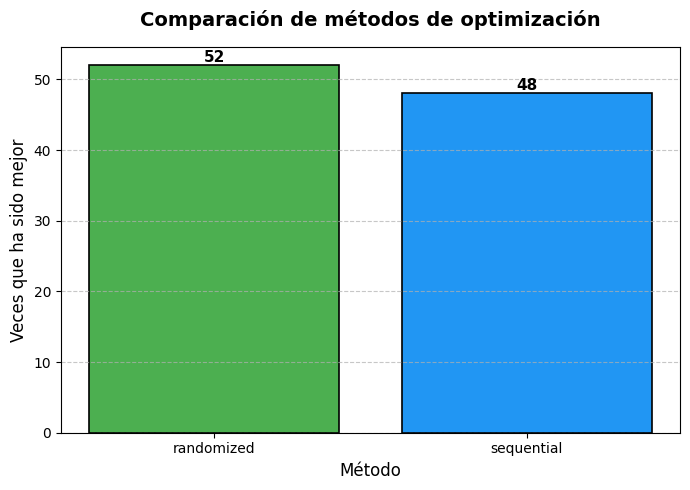

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

c = Counter({'randomized': 52, 'sequential': 48})

# Aseguramos que existan ambas claves
for key in ['randomized', 'sequential']:
    c.setdefault(key, 0)

plt.figure(figsize=(7, 5))

# Colores personalizados
colors = ['#4CAF50', '#2196F3']

# Crear gráfico de barras con estilo
bars = plt.bar(c.keys(), c.values(), color=colors, edgecolor='black', linewidth=1.2)

# Añadir etiquetas sobre las barras
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.05,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.title('Comparación de métodos de optimización', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Método', fontsize=12)
plt.ylabel('Veces que ha sido mejor', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()


# Estudio de diferentes valores de T utilizando diferentes métodos para reducir el valor

Modifico el algoritmo aleatorizado para poder específicar que operación utilizo para reducir el valor de T.
* primero es T-i*α
* segundo es T*α
* tercero es T/(1+αT)

In [ ]:
import random
from math import exp

def simulated_annealing_aleatorizado(individuo, objetos_cantidad, fitness, validar,
                                              T_inicial=50, T_min=1e-3, alpha=0.95,
                                              metodo='primero', max_iter=5000, verbose=False):
    """
    Recocido simulado generando len(individuo) vecinos por iteración.
    """
    fitness_history = []
    mejor = individuo[:]
    individuo_actual = individuo[:]
    fitness_actual = fitness(individuo_actual)
    max_fitness = fitness_actual

    generaciones_sin_mejora = 0
    max_generaciones_sin_mejora = 500
    T = T_inicial
    i = 0

    while i < max_iter and T > T_min:
        cambio = False

        # Generar len(individuo) vecinos
        indices = list(range(len(individuo_actual)))
        random.shuffle(indices)
        for j in indices:
            for k in [-1, 1]:
              prev = individuo_actual[j]

              # Generamos el vecino respetando límites
              if individuo_actual[j] == 0 and k == -1:
                  continue
              if k == 1 and individuo_actual[j] == objetos_cantidad[j]:
                  continue

              individuo_actual[j] += k
              nuevo_fitness = fitness(individuo_actual)
              diferencia = nuevo_fitness - fitness_actual

              # Criterio de aceptación
              if diferencia > 0 or random.random() < exp(diferencia / T):
                  fitness_actual = nuevo_fitness
                  if nuevo_fitness > max_fitness:
                      max_fitness = nuevo_fitness
                      mejor = individuo_actual[:]
                      cambio = True
              else:
                  individuo_actual[j] = prev

        # Control de estancamiento
        if not cambio:
            generaciones_sin_mejora += 1
        else:
            generaciones_sin_mejora = 0

        if generaciones_sin_mejora >= max_generaciones_sin_mejora:
            individuo_actual = populate()
            fitness_actual = fitness(individuo_actual)
            generaciones_sin_mejora = 0
            if verbose:
                print(f"Estancado {max_generaciones_sin_mejora} iteraciones, perturbando individuo...")

        if metodo == 'primero':
          T = T -i*alpha
        elif metodo == 'segundo':
          T = T * alpha
        else:
          T = T/(1 + alpha*T)
        i += 1
        fitness_history.append(fitness_actual)

        if verbose:
            print(f"Iteración {i} | T={T:.4f} | Mejor fitness={max_fitness} | Es válido: {validar(mejor)}")

    return mejor, max_fitness, fitness_history


Para cada método se pruebas diferentes valores de α para estudiar cual valor es mejor y para luego obtener que método de reducción de la T es mejor

In [ ]:
mejores_metodos_t = []
mejores_alphas = []
alphas = [0.85, 0.9, 0.95, 0.99]
import random


for i in range(50):
  individuo = populate()
  random.seed(i)
  n_objetos = 200
  capacidad_mochila = 600

  limite_objetos = n_objetos // 3

  objetos_peso = [random.randint(3, 60) for _ in range(n_objetos)]
  objetos_valor = [random.randint(10, 150) for _ in range(n_objetos)]
  objetos_cantidad = [random.randint(2, 15) for _ in range(n_objetos)]

  mejor_metodo_t = None
  mejor_alpha = None
  mejor_fitness = float('-inf')
  for alpha in alphas:
    _, max_fit1, fitness_history = simulated_annealing_aleatorizado(individuo, objetos_cantidad, fitness, validar, T_inicial=100, T_min=1e-5, alpha=alpha, metodo='primero', max_iter=5000)
    _, max_fit2, fitness_history = simulated_annealing_aleatorizado(individuo, objetos_cantidad, fitness, validar, T_inicial=100, T_min=1e-5, alpha=alpha, metodo='segundo', max_iter=5000)
    _, max_fit3, fitness_history = simulated_annealing_aleatorizado(individuo, objetos_cantidad, fitness, validar, T_inicial=100, T_min=1e-5, alpha=alpha, metodo='tercero', max_iter=5000)

    if max_fit1 >= max_fit2 and max_fit1 >= max_fit3 and max_fit1 > mejor_fitness:
      mejor_fitness = max_fit1
      mejor_metodo_t = "primero"
      mejor_alpha = alpha
    elif max_fit2 >= max_fit1 and max_fit2 >= max_fit3 and max_fit2 > mejor_fitness:
      mejor_fitness = max_fit2
      mejor_metodo_t = "segundo"
      mejor_alpha = alpha
    else:
      mejor_fitness = max_fit3
      mejor_metodo_t = "tercero"
      mejor_alpha = alpha

  mejores_metodos_t.append(mejor_metodo_t)
  mejores_alphas.append(mejor_alpha)

  print(f"Iteración {i+1}/50 completada - Mejor método: {mejores_metodos_t[-1]} - Mejor alpha: {mejores_alphas[-1]}")

Iteración 1/50 completada - Mejor método: segundo - Mejor alpha: 0.99
Iteración 2/50 completada - Mejor método: segundo - Mejor alpha: 0.99
Iteración 3/50 completada - Mejor método: segundo - Mejor alpha: 0.99
Iteración 4/50 completada - Mejor método: segundo - Mejor alpha: 0.99
Iteración 5/50 completada - Mejor método: segundo - Mejor alpha: 0.99
Iteración 6/50 completada - Mejor método: segundo - Mejor alpha: 0.99
Iteración 7/50 completada - Mejor método: segundo - Mejor alpha: 0.99
Iteración 8/50 completada - Mejor método: tercero - Mejor alpha: 0.99
Iteración 9/50 completada - Mejor método: segundo - Mejor alpha: 0.99
Iteración 10/50 completada - Mejor método: segundo - Mejor alpha: 0.99
Iteración 11/50 completada - Mejor método: segundo - Mejor alpha: 0.99
Iteración 12/50 completada - Mejor método: tercero - Mejor alpha: 0.99
Iteración 13/50 completada - Mejor método: tercero - Mejor alpha: 0.99
Iteración 14/50 completada - Mejor método: tercero - Mejor alpha: 0.99
Iteración 15/50

# Gráfica con los resultados del método de reducción de T

La mejor reducción de T ha sido T*α siendo mejor en 36 de las 50 instancias probadas

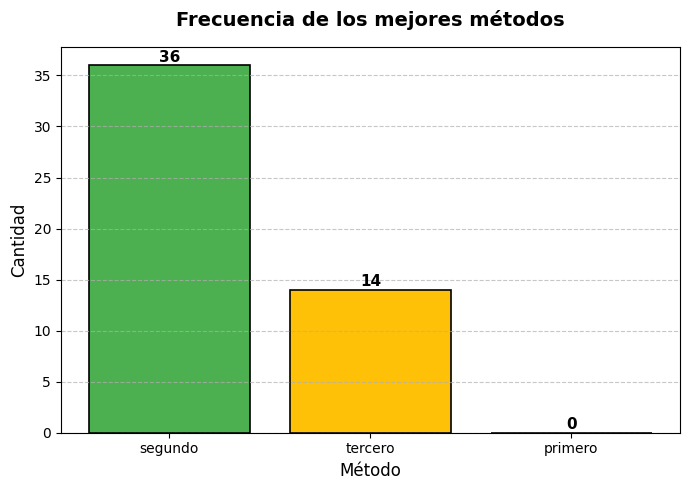

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

c2 = Counter(mejores_metodos_t)

for key in ['primero', 'segundo', 'tercero']:
    c2.setdefault(key, 0)

plt.figure(figsize=(7, 5))

colors = ['#4CAF50', '#FFC107', '#2196F3']

bars = plt.bar(c2.keys(), c2.values(), color=colors, edgecolor='black', linewidth=1.2)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.05,
        f'{height}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.title('Frecuencia de los mejores métodos', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Método', fontsize=12)
plt.ylabel('Cantidad', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()


El mejor valor de α ha sido 0.99, siendo el mejor en todas las instancias

In [ ]:
c3 = Counter(mejores_alphas)
print(c3)

Counter({0.99: 50})


# Pruebas de diferentes valores iniciales de T

A partir de los valores [10, 30, 50, 70, 100, 200], se ejecutan 100 instancias diferentes aplicando los distintos valores de T iniciales para evaluar cual produce mejores resultados.

In [ ]:
t_iniciales = [10, 30, 50, 70, 100, 200]

resultados_t = []

for i in range(100):
  individuo = populate()
  random.seed(i)
  n_objetos = 200
  capacidad_mochila = 600

  limite_objetos = n_objetos // 3

  objetos_peso = [random.randint(3, 60) for _ in range(n_objetos)]
  objetos_valor = [random.randint(10, 150) for _ in range(n_objetos)]
  objetos_cantidad = [random.randint(2, 15) for _ in range(n_objetos)]

  mejor_fitness = float('-inf')
  mejor_t = None
  for t in t_iniciales:
    _, fit, _ = simulated_annealing_aleatorizado(individuo, objetos_cantidad, fitness, validar, T_inicial=t, T_min=1e-5, alpha=0.99, metodo='segundo', max_iter=5000)

    if fit > mejor_fitness:
      mejor_fitness = fit
      mejor_t = t

  resultados_t.append(mejor_t)
  print(f"Iteración {i+1}/100 completada - Mejor t inicial: {resultados_t[-1]}")


Iteración 1/100 completada - Mejor t inicial: 200
Iteración 2/100 completada - Mejor t inicial: 100
Iteración 3/100 completada - Mejor t inicial: 100
Iteración 4/100 completada - Mejor t inicial: 200
Iteración 5/100 completada - Mejor t inicial: 30
Iteración 6/100 completada - Mejor t inicial: 100
Iteración 7/100 completada - Mejor t inicial: 70
Iteración 8/100 completada - Mejor t inicial: 100
Iteración 9/100 completada - Mejor t inicial: 200
Iteración 10/100 completada - Mejor t inicial: 100
Iteración 11/100 completada - Mejor t inicial: 200
Iteración 12/100 completada - Mejor t inicial: 50
Iteración 13/100 completada - Mejor t inicial: 50
Iteración 14/100 completada - Mejor t inicial: 200
Iteración 15/100 completada - Mejor t inicial: 200
Iteración 16/100 completada - Mejor t inicial: 70
Iteración 17/100 completada - Mejor t inicial: 100
Iteración 18/100 completada - Mejor t inicial: 50
Iteración 19/100 completada - Mejor t inicial: 100
Iteración 20/100 completada - Mejor t inicial:

In [ ]:
print(resultados_t)

[200, 100, 100, 200, 30, 100, 70, 100, 200, 100, 200, 50, 50, 200, 200, 70, 100, 50, 100, 30, 100, 100, 30, 70, 200, 100, 200, 100, 100, 30, 100, 70, 50, 100, 70, 30, 50, 100, 100, 200, 200, 30, 50, 200, 200, 30, 200, 100, 30, 100, 10, 200, 50, 200, 30, 200, 100, 30, 50, 50, 100, 70, 50, 50, 50, 200, 30, 200, 200, 30, 100, 30, 100, 100, 70, 200, 70, 50, 50, 50, 100, 200, 100, 70, 100, 100, 50, 30, 50, 100, 200, 200, 50, 200, 70, 200, 200, 30, 100, 100]


# Gráfica con los mejores valores iniciales de T

A medida que se incrementa el valor inicial de T, se obtenías mejores resultados, esto es debido a que cuanto mayor es el valor, más vecinos podremos generar y de esta forma se puede realizar mayor exploración

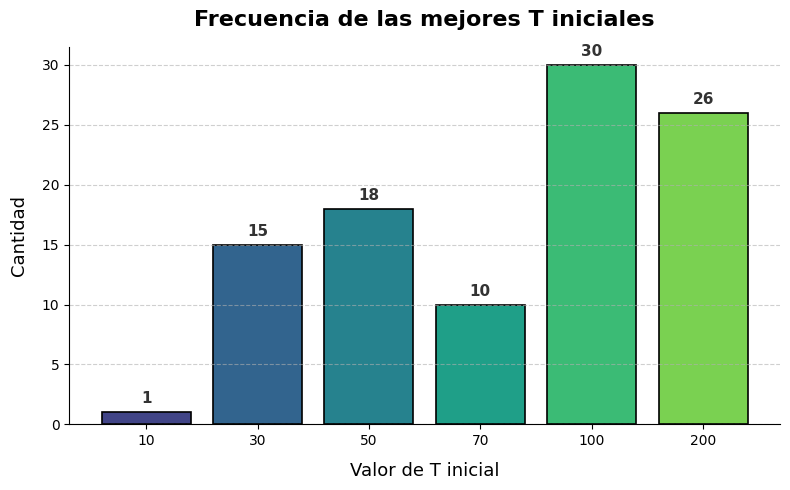

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
# Datos
c_t = Counter(resultados_t)

# Ordenar por clave para mejor visualización
keys = sorted(c_t.keys())
values = [c_t[k] for k in keys]

# Crear la figura
plt.figure(figsize=(8, 5))
bars = plt.bar(
    [str(k) for k in keys],
    values,
    color=plt.cm.viridis(np.linspace(0.2, 0.8, len(keys))),
    edgecolor='black',
    linewidth=1.2
)

# Añadir etiquetas de texto encima de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        color='#333333'
    )

plt.title('Frecuencia de las mejores T iniciales', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Valor de T inicial', fontsize=13, labelpad=10)
plt.ylabel('Cantidad', fontsize=13, labelpad=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)

for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


# Resultados obtenidos con el algoritmo seleccionado

En esta sección se muestra el algoritmo de enfriamiento simulado aplicándole los mejores parámetros encontrados con los tests realizados

In [ ]:
T_inicial = 100
alpha = 0.99
metodo = "segundo"
mejor_solucion_fit = float('-inf')
fitness_history_soluciones = []
mejor_solucion = None

for i in range(100):
    individuo = populate()
    mejor, max_fit, fitness_history = simulated_annealing_aleatorizado(individuo, objetos_cantidad, fitness, validar, T_inicial=T_inicial,metodo=metodo,alpha=alpha)

    if max_fit > mejor_solucion_fit:
      print(max_fit, mejor_solucion_fit)
      mejor_solucion_fit = max_fit
      mejor_solucion = mejor
      fitness_history_soluciones = fitness_history

    print(f"Mejor fitness: {max_fit} - Es válido: {validar(mejor)} - {i+1}/100")


8983 -inf
Mejor fitness: 8983 - Es válido: (True, []) - 1/100
Mejor fitness: 8784 - Es válido: (True, []) - 2/100
Mejor fitness: 8907 - Es válido: (True, []) - 3/100
Mejor fitness: 8983 - Es válido: (True, []) - 4/100
9015 8983
Mejor fitness: 9015 - Es válido: (True, []) - 5/100


9015


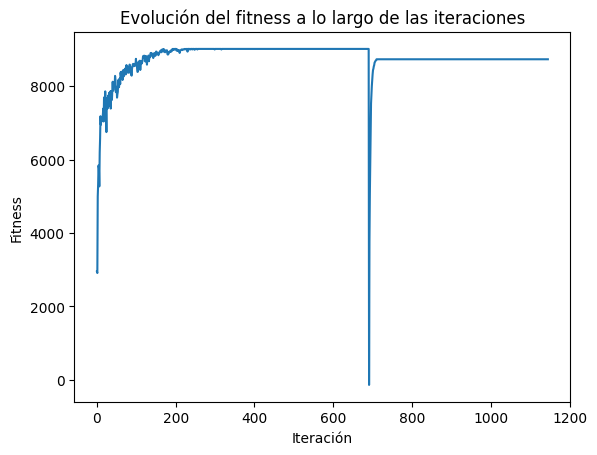

In [ ]:
import matplotlib.pyplot as plt

plt.plot(fitness_history_soluciones)
plt.xlabel('Iteración')
plt.ylabel('Fitness')
plt.title('Evolución del fitness a lo largo de las iteraciones')
print(mejor_solucion_fit)